# 📈 Prophet Time-Series-Workflow
**Generisches Notebook für Zeitreihenanalyse mit Facebook Prophet**

Dieses Notebook implementiert einen robusten, 12-stufigen Workflow:

1. **Daten laden** – CSV einlesen, `ds`/`y`-Format erzeugen
2. **Sichtprüfung** – Trend, Saisonalität, Ausreißer, Strukturbrüche?
3. **Datenaufbereitung** – Ausreißer → NaN setzen (Prophet verarbeitet NaNs nativ)
4. **Wachstumsmodell** – linear vs. logistic (+ Cap/Floor)
5. **Saisonalitätsmodus** – additiv vs. multiplikativ
6. **Features & Events** – `add_seasonality()`, Feiertage, externe Regressoren
7. **Modell fitten** – Prophet konfigurieren und trainieren
8. **Komponentenanalyse** – Zerlegung auf Plausibilität prüfen
9. **Cross-Validation & Tuning** – Grid Search über Prior-Scales
10. **Metriken auswerten** – MAE, RMSE, MAPE bewerten
11. **Residuenanalyse** – Systematische Muster aufspüren
12. **Prognose** – Forecast + Konfidenzintervall

### Iterationsschleifen

- **Metriken unbefriedigend** (Schritt 10) → Modellstruktur überdenken ab **Schritt 5**
- **Muster in Residuen** (Schritt 11) → Saisonalität / Regressoren ergänzen ab **Schritt 6**

---

## 0 – Imports

In [ ]:
# Abhängigkeiten installieren (nur beim ersten Mal nötig)
%pip install pandas matplotlib prophet --quiet

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

# Nur Prophet-interne Logging-Meldungen unterdrücken (nicht alle Warnungen!)
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

plt.rcParams.update({"figure.figsize": (12, 4), "figure.dpi": 100})

d:\05_VSCode\05_Python\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


---
## 1 – Daten laden

> Prophet erwartet ein DataFrame mit genau zwei Spalten:
> - **`ds`** – Zeitstempel (datetime)
> - **`y`** – Messwert (numerisch)
>
> Einfach die Variable `DATENSATZ` ändern und alles neu ausführen.

In [2]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> HIER DATENSATZ WÄHLEN <<<                       ║
# ║  Optionen: "AirPassengers", "UKgas",                 ║
# ║            "USAccDeaths", "Temperatur"                ║
# ╚══════════════════════════════════════════════════════╝

DATENSATZ = "AirPassengers"  # <-- ändern!

In [ ]:
def lade_datensatz(name: str) -> tuple[pd.DataFrame, str]:
    """
    Lädt einen der vier Datensätze und gibt ein Prophet-kompatibles
    DataFrame (ds, y) sowie die Frequenz-Bezeichnung zurück.
    """

    if name == "AirPassengers":
        df = pd.read_csv("Datasets/AirPassengers.csv")
        ds = pd.to_datetime(df["Month"])
        y = df["Passengers"].values.astype(float)
        freq = "MS"  # Monatsanfang

    elif name == "UKgas":
        df = pd.read_csv("UKgas.csv")
        idx = pd.PeriodIndex.from_fields(
            year=df["time"].astype(int),
            quarter=((df["time"] % 1) * 4 + 1).astype(int),
            freq="Q",
        ).to_timestamp()
        ds = idx
        y = df["value"].values.astype(float)
        freq = "QS"  # Quartalsanfang

    elif name == "USAccDeaths":
        df = pd.read_csv("USAccDeaths.csv")
        start_year = int(df["time"].iloc[0])
        ds = pd.date_range(start=f"{start_year}-01", periods=len(df), freq="MS")
        y = df["value"].values.astype(float)
        freq = "MS"

    elif name == "Temperatur":
        df = pd.read_csv("syn_temperatur_df.csv")
        ds = pd.to_datetime(df["Timestamp"])
        y = df["Temperature (°C)"].values.astype(float)
        freq = "h"  # stündlich

    elif name == "zrsyn":
        df = pd.read_csv("Datasets/zrsyn.csv")
        idx = pd.to_datetime(df["Period"])
        ts = pd.Series(df["Value"].values, index=idx, name="werte")
        ts.index.freq = "ME"
        m = 12  # stündlich → Tages-Saisonalität
    else:
        raise ValueError(f"Unbekannter Datensatz: {name}")

    df_prophet = pd.DataFrame({"ds": ds, "y": y})

    print(f"Datensatz:  {name}")
    print(f"Zeitraum:   {df_prophet['ds'].iloc[0].date()} bis {df_prophet['ds'].iloc[-1].date()}")
    print(f"Anzahl:     {len(df_prophet)} Beobachtungen")
    print(f"Frequenz:   {freq}")
    return df_prophet, freq


df_raw, FREQ = lade_datensatz(DATENSATZ)
df_raw.head()

Datensatz:  AirPassengers
Zeitraum:   1949-01-01 bis 1960-12-01
Anzahl:     144 Beobachtungen
Frequenz:   MS


,ds,y
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


---
## 2 – Sichtprüfung

Vier Fragen für die visuelle Inspektion:

| Frage | Hinweise |
|-------|----------|
| **Trend?** | Steigend, fallend, abflachend? → Wachstumsmodell (Schritt 4) |
| **Saisonalität?** | Wiederkehrendes Muster? Wie viele Perioden pro Zyklus? |
| **Wachsende Amplitude?** | Schwankungen nehmen zu? → multiplikativer Modus (Schritt 5) |
| **Ausreißer / Strukturbrüche?** | Einzelne Spitzen, plötzliche Niveauänderung? → Schritt 3 |

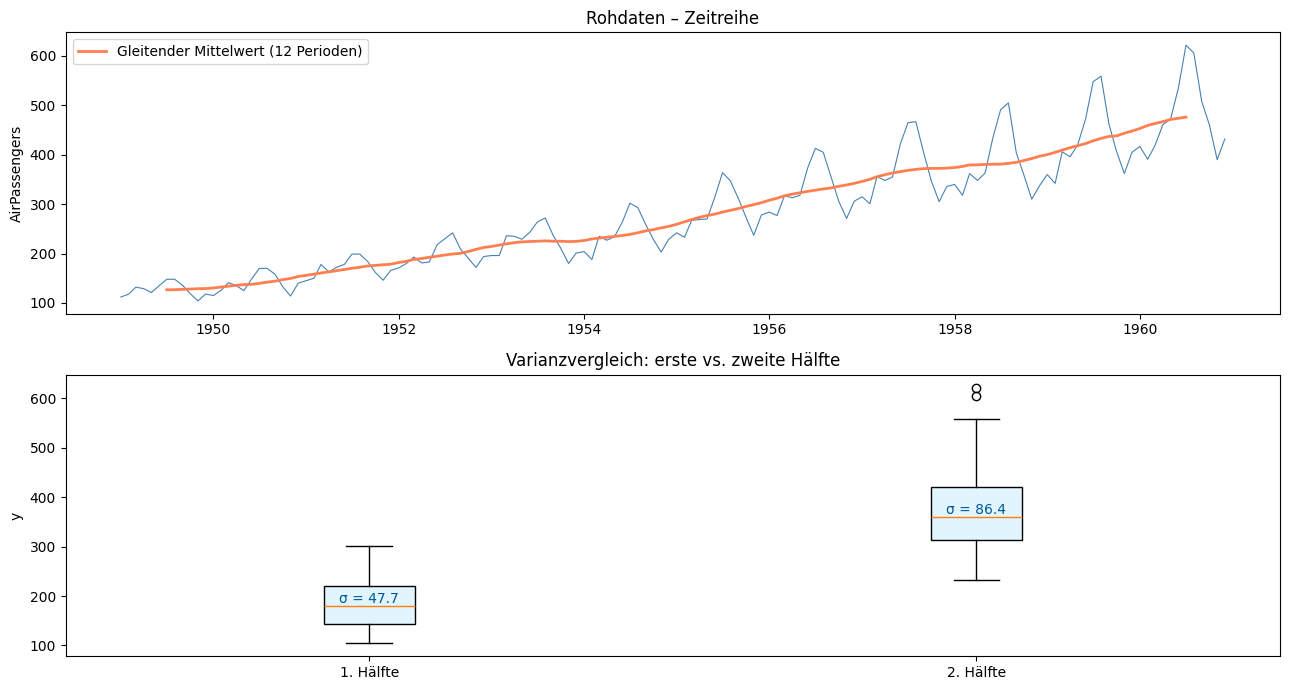


→ Prüfe:
  1. Steigt/fällt der Trend linear oder flacht er ab?
     Linear → Schritt 4: growth='linear'
     Abflachend / begrenzt → Schritt 4: growth='logistic'
  2. Ist σ in der 2. Hälfte deutlich größer als in der 1.?
     Ja → Schritt 5: seasonality_mode='multiplicative'
     Nein → Schritt 5: seasonality_mode='additive'


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# --- Rohdaten ---
axes[0].plot(df_raw["ds"], df_raw["y"], color="steelblue", linewidth=0.8)
axes[0].set_title("Rohdaten – Zeitreihe")
axes[0].set_ylabel(DATENSATZ)

# --- Gleitender Mittelwert zum Erkennen des Trends ---
fenster = {"MS": 12, "QS": 4, "h": 24}.get(FREQ, 12)
rolling_mean = df_raw.set_index("ds")["y"].rolling(window=fenster, center=True).mean()
axes[0].plot(rolling_mean.index, rolling_mean.values, color="coral",
             linewidth=2, label=f"Gleitender Mittelwert ({fenster} Perioden)")
axes[0].legend()

# --- Varianzvergleich erste vs. zweite Hälfte ---
halbzeit = len(df_raw) // 2
erste_haelfte = df_raw["y"].iloc[:halbzeit]
zweite_haelfte = df_raw["y"].iloc[halbzeit:]

bp = axes[1].boxplot(
    [erste_haelfte, zweite_haelfte],
    tick_labels=["1. Hälfte", "2. Hälfte"],
    patch_artist=True,
    boxprops=dict(facecolor="#e1f5fe"),
)
axes[1].set_title("Varianzvergleich: erste vs. zweite Hälfte")
axes[1].set_ylabel("y")

for teil, x in [(erste_haelfte, 1), (zweite_haelfte, 2)]:
    axes[1].annotate(f"σ = {teil.std():.1f}", xy=(x, teil.median()),
                     fontsize=10, ha="center", va="bottom", color="#01579b")

plt.tight_layout()
plt.show()

print("\n→ Prüfe:")
print("  1. Steigt/fällt der Trend linear oder flacht er ab?")
print("     Linear → Schritt 4: growth='linear'")
print("     Abflachend / begrenzt → Schritt 4: growth='logistic'")
print("  2. Ist σ in der 2. Hälfte deutlich größer als in der 1.?")
print("     Ja → Schritt 5: seasonality_mode='multiplicative'")
print("     Nein → Schritt 5: seasonality_mode='additive'")

---
## 3 – Datenaufbereitung

Prophet ist empfindlich gegenüber **Ausreißern** – einzelne Spikes können
Changepoints verzerren. Die empfohlene Strategie:

1. Ausreißer identifizieren (z. B. > 3 Standardabweichungen vom gleitenden Mittel)
2. Auf `NaN` setzen

> **Wichtig:** Prophet verarbeitet `NaN`-Werte **nativ** – es überspringt
> diese Zeilen beim Fitten automatisch. Deshalb ist `NaN`-Setzen die
> korrekte und ausreichende Methode. Eine Interpolation ist weder
> nötig noch empfehlenswert, da sie künstliche Datenpunkte erzeugt,
> die das Modell als echte Beobachtungen behandeln würde.

In [6]:
df = df_raw.copy()

# --- Ausreißer-Erkennung via gleitender Statistik ---
rolling = df.set_index("ds")["y"].rolling(window=fenster, center=True)
rolling_mean = rolling.mean()
rolling_std = rolling.std()

# Grenze: 3 Standardabweichungen vom lokalen Mittelwert
SCHWELLE = 3.0  # <-- bei Bedarf anpassen

abweichung = (df.set_index("ds")["y"] - rolling_mean).abs()
ist_ausreisser = abweichung > SCHWELLE * rolling_std

n_ausreisser = ist_ausreisser.sum()
print(f"Erkannte Ausreißer (>{SCHWELLE}σ): {n_ausreisser}")

if n_ausreisser > 0:
    # Ausreißer auf NaN setzen – Prophet überspringt diese Zeilen nativ
    df.loc[ist_ausreisser.values, "y"] = np.nan
    print(f"→ {n_ausreisser} Werte auf NaN gesetzt (keine Interpolation nötig).")

    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(df_raw["ds"], df_raw["y"], ".", color="lightgray", label="Original", markersize=3)
    ax.plot(df["ds"], df["y"], color="steelblue", linewidth=0.8, label="Bereinigt")
    ax.set_title("Zeitreihe nach Ausreißerbehandlung")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("→ Keine Ausreißer erkannt – Daten unverändert.")

print(f"\nNaN-Werte im Datensatz: {df['y'].isna().sum()} (werden von Prophet übersprungen)")

Erkannte Ausreißer (>3.0σ): 0
→ Keine Ausreißer erkannt – Daten unverändert.

NaN-Werte im Datensatz: 0 (werden von Prophet übersprungen)


---
## 4 – Wachstumsmodell wählen

Prophet unterstützt zwei Wachstumsmodelle:

| Modell | Wann geeignet? | Erfordert |
|--------|---------------|----------|
| `linear` | Trend steigt/fällt ohne erkennbare Sättigungsgrenze | nichts |
| `logistic` | Wachstum flacht ab, es gibt eine natürliche Obergrenze | `cap` (und optional `floor`) |

> **Entscheidungshilfe:** Wenn die Reihe aus Schritt 2 einen klar linearen
> Trend zeigt, ist `linear` die richtige Wahl. Bei begrenztem Wachstum
> (z. B. Marktdurchdringung, Ressourcenverbrauch) → `logistic`.

In [7]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> WACHSTUMSMODELL WÄHLEN <<<                      ║
# ║  Basierend auf der Sichtprüfung in Schritt 2:        ║
# ║  "linear"   → linearer Trend                         ║
# ║  "logistic" → begrenztes Wachstum (Cap/Floor nötig!) ║
# ╚══════════════════════════════════════════════════════╝

GROWTH = "linear"  # <-- hier eintragen: "linear" oder "logistic"

# --- Nur bei logistic: Sättigungsgrenzen setzen ---
if GROWTH == "logistic":
    CAP = df["y"].max() * 1.2    # <-- Obergrenze anpassen!
    FLOOR = 0                     # <-- Untergrenze anpassen!
    df["cap"] = CAP
    df["floor"] = FLOOR
    print(f"Logistic Growth: Cap = {CAP:.1f}, Floor = {FLOOR:.1f}")
else:
    print("Linear Growth – keine Sättigungsgrenzen nötig.")

print(f"\n★ Wachstumsmodell: {GROWTH}")

Linear Growth – keine Sättigungsgrenzen nötig.

★ Wachstumsmodell: linear


---
## 5 – Saisonalitätsmodus wählen

Der Saisonalitätsmodus bestimmt, wie saisonale Schwankungen mit dem Trend
interagieren. Er ersetzt konzeptionell die Log-Transformation aus dem
SARIMA-Workflow:

| Modus | Bedeutung | Wann? |
|-------|-----------|-------|
| `additive` | Saisonale Schwankung ist **konstant** in absoluten Werten | Amplitude bleibt über die Zeit gleich |
| `multiplicative` | Saisonale Schwankung ist **proportional** zum Trend | Amplitude wächst mit dem Niveau |

> **Faustregel aus Schritt 2:** Wenn σ in der 2. Hälfte deutlich größer ist
> als in der 1. Hälfte → `multiplicative`.
>
> **Iterationshinweis:** Wenn die Metriken in Schritt 10 trotz Tuning
> unbefriedigend bleiben, hierhin zurückkehren und den Modus wechseln.

In [8]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> SAISONALITÄTSMODUS WÄHLEN <<<                   ║
# ║  Basierend auf dem Varianzvergleich aus Schritt 2:    ║
# ║  "additive"       → konstante Schwankungsbreite      ║
# ║  "multiplicative" → wachsende Schwankungsbreite      ║
# ╚══════════════════════════════════════════════════════╝

SEASONALITY_MODE = "multiplicative"  # <-- hier eintragen!

print(f"★ Saisonalitätsmodus: {SEASONALITY_MODE}")

★ Saisonalitätsmodus: multiplicative


---
## 6 – Features & Events

Prophet bietet drei Mechanismen, um domänenspezifisches Wissen einzubringen.
Jeder adressiert eine andere Art von Effekt:

| Mechanismus | API | Wann einsetzen? |
|-------------|-----|----------------|
| **Zusätzliche Saisonalität** | `add_seasonality(name, period, fourier_order)` | Periodisches Muster, das Prophet nicht automatisch erkennt (z. B. Wochentag bei Monatsdaten) |
| **Feiertage / Events** | `holidays`-DataFrame | Kalendereffekte mit bekannten Daten (Weihnachten, Black Friday, …) |
| **Externe Regressoren** | `add_regressor(name)` | Erklärende Variablen, die keine feste Periode haben (z. B. Temperatur, Werbeausgaben) |

> Für die Übungsdatensätze beginnen wir ohne zusätzliche Features.
> In Schritt 11 kann sich zeigen, dass hier nachgebessert werden muss.

> **Iterationshinweis:** Wenn die Residuen in Schritt 11 systematische
> Muster zeigen, hierhin zurückkehren und Features ergänzen.

In [9]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> FEATURES & EVENTS DEFINIEREN (optional) <<<     ║
# ║  Beim ersten Durchlauf: leer lassen.                 ║
# ║  Nach Schritt 11 (Residuen): hier ergänzen und       ║
# ║  ab Schritt 6 erneut ausführen.                      ║
# ╚══════════════════════════════════════════════════════╝

# --- Zusätzliche Saisonalitäten ---
# Liste von Dicts, die in Schritt 7 an add_seasonality() übergeben werden.
# Beispiel für Stundendaten mit wöchentlicher Saisonalität:
#
# EXTRA_SEASONALITIES = [
#     {"name": "wochentag", "period": 7, "fourier_order": 3},
# ]

EXTRA_SEASONALITIES = []  # <-- bei Bedarf ergänzen

# --- Feiertage / Events ---
# Beispiel:
# feiertage = pd.DataFrame({
#     "holiday": "weihnachten",
#     "ds": pd.to_datetime(["1949-12-25", "1950-12-25", "1951-12-25"]),
#     "lower_window": -2,   # 2 Tage vor dem Ereignis
#     "upper_window":  1,   # 1 Tag danach
# })

feiertage = None  # <-- auf DataFrame setzen, wenn gewünscht

# --- Externe Regressoren ---
# Spaltenname(n), die sowohl in df als auch im future-DataFrame
# vorhanden sein müssen:
#
# EXTRA_REGRESSORS = ["temperatur", "werbeausgaben"]

EXTRA_REGRESSORS = []  # <-- bei Bedarf ergänzen

# --- Zusammenfassung ---
print("Konfigurierte Features:")
print(f"  Zusätzliche Saisonalitäten: {len(EXTRA_SEASONALITIES)}")
print(f"  Feiertage:                  {'definiert' if feiertage is not None else 'keine'}")
print(f"  Externe Regressoren:        {len(EXTRA_REGRESSORS)}")

Konfigurierte Features:
  Zusätzliche Saisonalitäten: 0
  Feiertage:                  keine
  Externe Regressoren:        0


---
## 7 – Modell fitten

Hier wird das Modell mit den Einstellungen aus Schritt 4–6 aufgebaut
und auf den Daten trainiert. Die Changepoint-Priors werden hier noch
auf Defaults belassen – die **optimalen Werte** findet der Grid Search
in Schritt 9 automatisch.

| Parameter | Wirkung | Default |
|-----------|---------|--------|
| `changepoint_prior_scale` | Flexibilität des Trends | 0.05 |
| `seasonality_prior_scale` | Stärke der Saisonalität | 10 |
| `n_changepoints` | Anzahl potentieller Trendänderungspunkte | 25 |

In [10]:
N_CHANGEPOINTS = 25  # <-- bei Bedarf anpassen


def baue_modell(chg_prior: float = 0.05,
                sea_prior: float = 10.0) -> Prophet:
    """
    Baut ein Prophet-Modell mit den gewählten Strukturparametern
    (aus Schritt 4–6) und den übergebenen Prior-Scales.

    Diese Funktion wird sowohl hier als auch im Grid Search (Schritt 9)
    verwendet, damit die Modellstruktur konsistent bleibt.
    """
    m = Prophet(
        growth=GROWTH,
        seasonality_mode=SEASONALITY_MODE,
        changepoint_prior_scale=chg_prior,
        seasonality_prior_scale=sea_prior,
        n_changepoints=N_CHANGEPOINTS,
        holidays=feiertage,
        yearly_seasonality="auto",
        weekly_seasonality="auto",
        daily_seasonality="auto",
    )

    # Zusätzliche Saisonalitäten aus Schritt 6
    for s in EXTRA_SEASONALITIES:
        m.add_seasonality(**s)

    # Externe Regressoren aus Schritt 6
    for reg in EXTRA_REGRESSORS:
        m.add_regressor(reg)

    return m


# --- Erster Fit mit Defaults (Orientierung vor dem Grid Search) ---
modell = baue_modell()
modell.fit(df)

print(f"★ Modell gefittet (Default-Priors):")
print(f"  growth                  = {GROWTH}")
print(f"  seasonality_mode        = {SEASONALITY_MODE}")
print(f"  changepoint_prior_scale = 0.05 (Default)")
print(f"  seasonality_prior_scale = 10.0 (Default)")
print(f"  n_changepoints          = {N_CHANGEPOINTS}")
print(f"  Zusätzliche Saisonalitäten: {len(EXTRA_SEASONALITIES)}")
print(f"  Externe Regressoren:        {len(EXTRA_REGRESSORS)}")
print(f"  Feiertage:                  {'ja' if feiertage is not None else 'nein'}")

09:45:52 - cmdstanpy - INFO - Chain [1] start processing
09:45:52 - cmdstanpy - INFO - Chain [1] done processing


★ Modell gefittet (Default-Priors):
  growth                  = linear
  seasonality_mode        = multiplicative
  changepoint_prior_scale = 0.05 (Default)
  seasonality_prior_scale = 10.0 (Default)
  n_changepoints          = 25
  Zusätzliche Saisonalitäten: 0
  Externe Regressoren:        0
  Feiertage:                  nein


---
## 8 – Komponentenanalyse

`plot_components()` zerlegt die Zeitreihe in ihre gelernten Bestandteile.
Hier prüfen wir auf **Plausibilität**:

- Sieht der **Trend** realistisch aus, oder gibt es unerwartete Sprünge?
- Hat die **Saisonalität** die erwartete Form?
- Falls Feiertage definiert: Sind die Effekte in der richtigen Größenordnung?

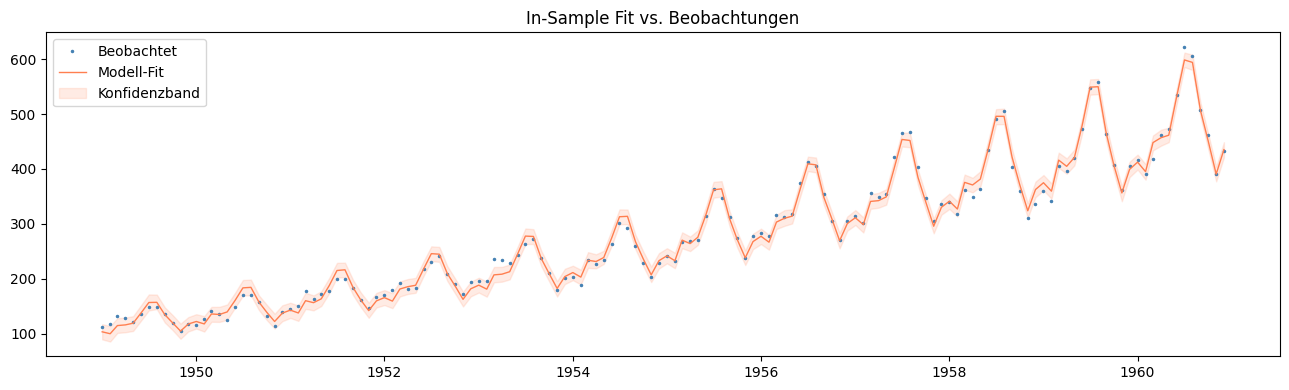

In [11]:
# In-Sample-Vorhersage (zum Vergleich mit den Beobachtungen)
df_pred = modell.predict(df)

# --- Fit vs. Beobachtung ---
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["ds"], df["y"], ".", color="steelblue", markersize=3, label="Beobachtet")
ax.plot(df_pred["ds"], df_pred["yhat"], color="coral", linewidth=1, label="Modell-Fit")
ax.fill_between(df_pred["ds"], df_pred["yhat_lower"], df_pred["yhat_upper"],
                color="coral", alpha=0.15, label="Konfidenzband")
ax.set_title("In-Sample Fit vs. Beobachtungen")
ax.legend()
plt.tight_layout()
plt.show()

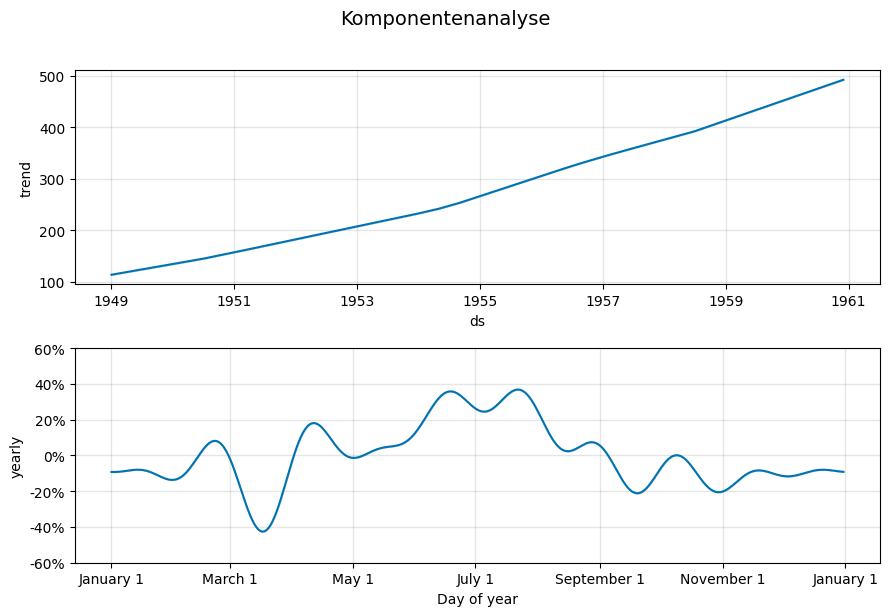

→ Prüfe:
  - Ist der Trend-Verlauf plausibel?
  - Stimmt die saisonale Wellenform mit dem Domänenwissen überein?
  - Falls Sprünge im Trend: n_changepoints ggf. reduzieren.


In [12]:
# --- Komponentenzerlegung ---
fig = modell.plot_components(df_pred)
plt.suptitle("Komponentenanalyse", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print("→ Prüfe:")
print("  - Ist der Trend-Verlauf plausibel?")
print("  - Stimmt die saisonale Wellenform mit dem Domänenwissen überein?")
print("  - Falls Sprünge im Trend: n_changepoints ggf. reduzieren.")

---
## 9 – Cross-Validation & Hyperparameter-Tuning

Statt die Hyperparameter manuell zu justieren, durchsuchen wir
systematisch ein **Parametergitter** per Cross-Validation.

Getunte Parameter:

| Parameter | Wirkung | Suchbereich |
|-----------|---------|-------------|
| `changepoint_prior_scale` | Trend-Flexibilität | 0.01 – 0.5 |
| `seasonality_prior_scale` | Saisonalitäts-Stärke | 0.1 – 10 |

Für jede Kombination wird eine Rolling-Origin-CV durchgeführt.
Das Modell mit dem **niedrigsten MAPE** wird als bestes gewählt
und automatisch auf den gesamten Datensatz nachgefittet.

> **Faustregel CV-Fenster:** `initial` ≥ 2× saisonale Zyklen,
> `horizon` = 1 saisonaler Zyklus.

In [13]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> ULTRA-SCHNELLES PARAMETER-TUNING <<<            ║
# ║  Ziel: < 30 Sekunden Laufzeit                        ║
# ╚══════════════════════════════════════════════════════╝

# --- EXTREM KLEINES PARAMETERGITTER ---
# Nur die 3 vielversprechendsten Kombinationen
param_combinations = [
    (0.05, 10.0),   # Prophet-Default
    (0.1, 10.0),    # Etwas flexibler
    (0.05, 1.0),    # Weniger flexible Saisonalität
    # (0.3, 10.0),  # Zu flexibel – oft Overfitting, daher rausgenommen
]

# --- EXTREM KURZE CV-PARAMETER FÜR GESCHWINDIGKEIT ---
# Diese Werte sind bewusst sehr kurz gewählt
cv_defaults = {
    "MS":  {"initial": "180 days", "period": "30 days", "horizon": "60 days"},
    "QS":  {"initial": "365 days", "period": "60 days", "horizon": "90 days"},
    "h":   {"initial": "60 hours", "period": "6 hours",  "horizon": "12 hours"},
}
cv_params = cv_defaults.get(FREQ, cv_defaults["MS"])

print(f"Ultra-Schnelles Tuning: {len(param_combinations)} Kombinationen")
print(f"CV-Parameter: {cv_params}\n")
print(f"{'Nr':>2s}  {'chg_prior':>8s}  {'sea_prior':>8s}  {'MAPE':>7s}  {'RMSE':>8s}")
print("-" * 48)

ergebnisse_grid = []

for i, (chg, sea) in enumerate(param_combinations, 1):
    # 1. Modell bauen und fitten
    m_candidate = baue_modell(chg_prior=chg, sea_prior=sea)
    m_candidate.fit(df)

    try:
        # 2. Cross-Validation durchführen
        df_cv_i = cross_validation(m_candidate, **cv_params, disable_tqdm=True)
        
        # 3. MAPE/RMSE MANUELL und VEKTORISIERT berechnen (schneller als performance_metrics!)
        #    Achtung: y und yhat können NaN sein, daher maskieren
        valid = df_cv_i[['y', 'yhat']].dropna()
        if len(valid) == 0:
            continue
            
        errors = valid['y'] - valid['yhat']
        rmse_i = (errors ** 2).mean() ** 0.5
        mape_i = (errors.abs() / valid['y'].abs()).mean()

    except Exception:
        # Bei jedem Fehler: Kombination überspringen
        continue

    ergebnisse_grid.append({
        "changepoint_prior_scale": chg,
        "seasonality_prior_scale": sea,
        "mape": mape_i,
        "rmse": rmse_i,
        "cv_detail": df_cv_i,
    })
    print(f"{i:2d}  {chg:8.3f}  {sea:8.1f}  {mape_i:>6.2%}  {rmse_i:>8.2f}")

# --- Bestes Modell auswählen und nachfitten ---
if not ergebnisse_grid:
    # Fallback: Default-Parameter verwenden
    print("\n⚠️  Tuning fehlgeschlagen. Verwende sichere Default-Werte.")
    CHANGEPOINT_PRIOR = 0.05
    SEASONALITY_PRIOR = 10.0
else:
    beste = min(ergebnisse_grid, key=lambda x: x["mape"])
    CHANGEPOINT_PRIOR = beste["changepoint_prior_scale"]
    SEASONALITY_PRIOR = beste["seasonality_prior_scale"]
    df_cv = beste["cv_detail"]

    print(f"\n★ Beste Kombination:")
    print(f"  changepoint_prior_scale = {CHANGEPOINT_PRIOR}")
    print(f"  seasonality_prior_scale = {SEASONALITY_PRIOR}")
    print(f"  MAPE = {beste['mape']:.2%}, RMSE = {beste['rmse']:.2f}")

# Modell mit (gefundenen oder default) Parametern auf dem gesamten Datensatz fitten
modell = baue_modell(chg_prior=CHANGEPOINT_PRIOR, sea_prior=SEASONALITY_PRIOR)
modell.fit(df)

print(f"\n✔ Modell nachgefittet – bereit für Schritt 10.")


09:46:16 - cmdstanpy - INFO - Chain [1] start processing
09:46:16 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
09:46:16 - cmdstanpy - INFO - Chain [1] start processing


Ultra-Schnelles Tuning: 3 Kombinationen
CV-Parameter: {'initial': '180 days', 'period': '30 days', 'horizon': '60 days'}

Nr  chg_prior  sea_prior     MAPE      RMSE
------------------------------------------------


09:46:18 - cmdstanpy - INFO - Chain [1] done processing
09:46:18 - cmdstanpy - INFO - Chain [1] start processing
09:46:19 - cmdstanpy - INFO - Chain [1] done processing
09:46:19 - cmdstanpy - INFO - Chain [1] start processing
09:46:20 - cmdstanpy - INFO - Chain [1] done processing
09:46:20 - cmdstanpy - INFO - Chain [1] start processing
09:46:22 - cmdstanpy - INFO - Chain [1] done processing
09:46:22 - cmdstanpy - INFO - Chain [1] start processing
09:46:23 - cmdstanpy - INFO - Chain [1] done processing
09:46:24 - cmdstanpy - INFO - Chain [1] start processing
09:46:26 - cmdstanpy - INFO - Chain [1] done processing
09:46:26 - cmdstanpy - INFO - Chain [1] start processing
09:46:30 - cmdstanpy - INFO - Chain [1] done processing
09:46:30 - cmdstanpy - INFO - Chain [1] start processing
09:46:34 - cmdstanpy - INFO - Chain [1] done processing
09:46:34 - cmdstanpy - INFO - Chain [1] start processing
09:46:36 - cmdstanpy - INFO - Chain [1] done processing
09:46:36 - cmdstanpy - INFO - Chain [1] 

 1     0.050      10.0  39.51%    301.00


09:48:21 - cmdstanpy - INFO - Chain [1] done processing
09:48:21 - cmdstanpy - INFO - Chain [1] start processing
09:48:25 - cmdstanpy - INFO - Chain [1] done processing
09:48:25 - cmdstanpy - INFO - Chain [1] start processing
09:48:28 - cmdstanpy - INFO - Chain [1] done processing
09:48:28 - cmdstanpy - INFO - Chain [1] start processing
09:48:32 - cmdstanpy - INFO - Chain [1] done processing
09:48:32 - cmdstanpy - INFO - Chain [1] start processing
09:48:36 - cmdstanpy - INFO - Chain [1] done processing
09:48:36 - cmdstanpy - INFO - Chain [1] start processing
09:48:41 - cmdstanpy - INFO - Chain [1] done processing
09:48:41 - cmdstanpy - INFO - Chain [1] start processing
09:48:46 - cmdstanpy - INFO - Chain [1] done processing
09:48:46 - cmdstanpy - INFO - Chain [1] start processing
09:48:48 - cmdstanpy - INFO - Chain [1] done processing
09:48:48 - cmdstanpy - INFO - Chain [1] start processing
09:48:51 - cmdstanpy - INFO - Chain [1] done processing
09:48:52 - cmdstanpy - INFO - Chain [1] 

 2     0.100      10.0  22.94%    151.20


09:51:16 - cmdstanpy - INFO - Chain [1] start processing
09:51:17 - cmdstanpy - INFO - Chain [1] done processing
09:51:17 - cmdstanpy - INFO - Chain [1] start processing
09:51:19 - cmdstanpy - INFO - Chain [1] done processing
09:51:19 - cmdstanpy - INFO - Chain [1] start processing
09:51:21 - cmdstanpy - INFO - Chain [1] done processing
09:51:21 - cmdstanpy - INFO - Chain [1] start processing
09:51:23 - cmdstanpy - INFO - Chain [1] done processing
09:51:23 - cmdstanpy - INFO - Chain [1] start processing
09:51:24 - cmdstanpy - INFO - Chain [1] done processing
09:51:25 - cmdstanpy - INFO - Chain [1] start processing
09:51:27 - cmdstanpy - INFO - Chain [1] done processing
09:51:27 - cmdstanpy - INFO - Chain [1] start processing
09:51:29 - cmdstanpy - INFO - Chain [1] done processing
09:51:29 - cmdstanpy - INFO - Chain [1] start processing
09:51:31 - cmdstanpy - INFO - Chain [1] done processing
09:51:31 - cmdstanpy - INFO - Chain [1] start processing
09:51:37 - cmdstanpy - INFO - Chain [1]

 3     0.050       1.0   8.64%     35.88

★ Beste Kombination:
  changepoint_prior_scale = 0.05
  seasonality_prior_scale = 1.0
  MAPE = 8.64%, RMSE = 35.88

✔ Modell nachgefittet – bereit für Schritt 10.


---
## 10 – Metriken auswerten

| Metrik | Interpretation |
|--------|---------------|
| **MAE** | Mittlerer absoluter Fehler – in der Einheit der Daten |
| **RMSE** | Bestraft große Fehler stärker als MAE |
| **MAPE** | Prozentualer Fehler – gut zum Vergleich zwischen Datensätzen |

> **Wenn die Metriken trotz Grid Search unbefriedigend sind:**
> Das Tuning hat die besten Priors bereits gefunden – das Problem
> liegt dann an der **Modellstruktur**. Zurück zu **Schritt 5**:
> Saisonalitätsmodus wechseln, oder zu **Schritt 4**: Wachstumsmodell
> überdenken.

Durchschnittliche Metriken über alle CV-Folds:
  MAE  = 15.73
  RMSE = 23.15
  MAPE = 6.95%


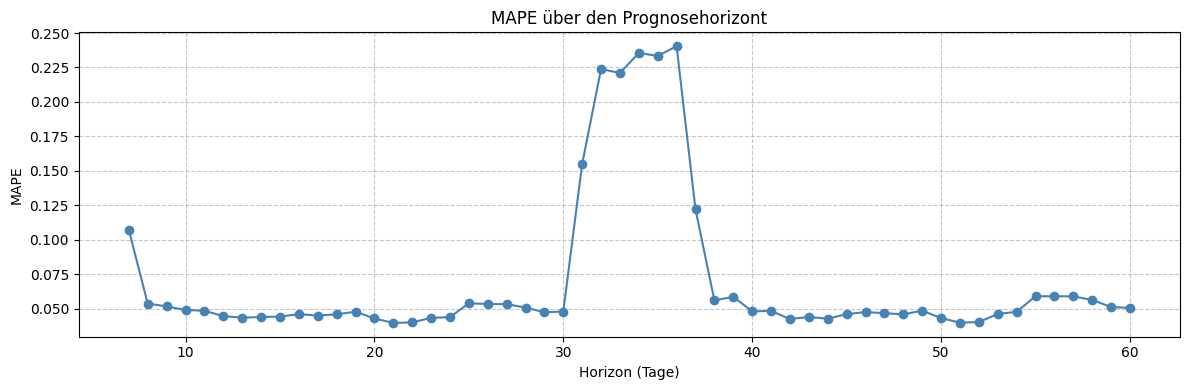


◐ MAPE 5–15 % – akzeptabel. Falls Verbesserung gewünscht:
  → Schritt 6: Feiertage oder Regressoren ergänzen
  → Schritt 5: Saisonalitätsmodus wechseln


In [14]:
# --- Metriken berechnen ---
if df_cv is not None:
    df_metrics = performance_metrics(df_cv)
    # Zusammenfassung
    print("Durchschnittliche Metriken über alle CV-Folds:")
    print(f"  MAE  = {df_metrics['mae'].mean():.2f}")
    print(f"  RMSE = {df_metrics['rmse'].mean():.2f}")
    print(f"  MAPE = {df_metrics['mape'].mean():.2%}")

    # --- ROBUSTER MAPE-PLOT (umgeht den Prophet-Plot-Fehler) ---
    # df_metrics enthält die Spalte 'horizon'
    plt.figure(figsize=(12, 4))
    plt.plot(df_metrics['horizon'].dt.days, df_metrics['mape'], 'o-', color='steelblue')
    plt.title("MAPE über den Prognosehorizont")
    plt.xlabel("Horizon (Tage)")
    plt.ylabel("MAPE")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    # Fallback, wenn keine CV durchgeführt wurde
    print("\n⚠️  Keine Cross-Validation durchgeführt. Berechne In-Sample-Metriken.")
    df_pred_full = modell.predict(df)
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import numpy as np

    # Nur nicht-NaN Werte berücksichtigen
    mask = ~np.isnan(df['y'])
    y_true = df['y'][mask]
    y_pred = df_pred_full['yhat'].iloc[mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"  MAE  = {mae:.2f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAPE = {mape:.2f}%")

# --- Bewertung der Metrik ---
# Wir verwenden den MAPE-Wert, den wir gerade berechnet haben
if df_cv is not None:
    mape_value = df_metrics["mape"].mean()
else:
    mape_value = mape / 100.0 # Normalisieren auf 0-1

if mape_value < 0.05:
    print("\n✔ MAPE < 5 % – sehr gute Prognosegüte.")
elif mape_value < 0.15:
    print("\n◐ MAPE 5–15 % – akzeptabel. Falls Verbesserung gewünscht:")
    print("  → Schritt 6: Feiertage oder Regressoren ergänzen")
    print("  → Schritt 5: Saisonalitätsmodus wechseln")
else:
    print("\n✗ MAPE > 15 % – Modellstruktur überdenken!")
    print("  → Schritt 5: Saisonalitätsmodus wechseln (additiv ↔ multiplikativ)")
    print("  → Schritt 4: Wachstumsmodell wechseln (linear ↔ logistic)")
    print("  → Schritt 6: zusätzliche Saisonalitäten oder Regressoren ergänzen")
    print("  Danach ab Schritt 5 erneut ausführen.")


---
## 11 – Residuenanalyse

Auch bei Prophet sollten die Residuen (**y − ŷ**) kein systematisches
Muster zeigen. Typische Befunde und Maßnahmen:

| Befund | Mögliche Ursache | Maßnahme |
|--------|-----------------|----------|
| Wiederkehrendes Muster | Fehlende Saisonalität | `add_seasonality()` in Schritt 6 |
| Autokorrelation | Saisonale Ordnung zu niedrig | `fourier_order` erhöhen (Schritt 6) |
| Einzelne große Ausreißer | Nicht erfasste Ereignisse | Feiertage in Schritt 6 ergänzen |
| Systematischer Bias | Trend-Fehlspezifikation | Wachstumsmodell überprüfen (Schritt 4) |

> **Iterationshinweis:** Bei Mustern → zurück zu **Schritt 6** (Features ergänzen),
> dann ab dort erneut ausführen.

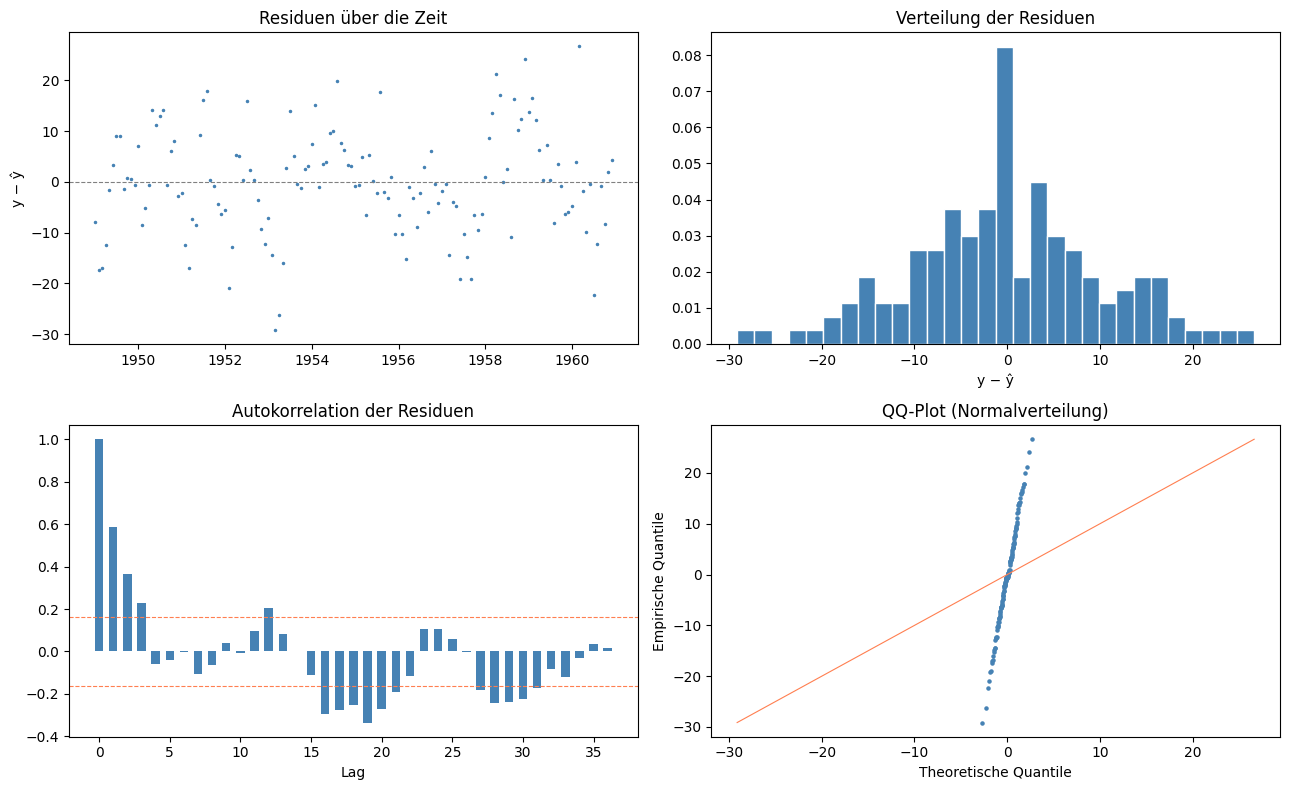

Signifikante Autokorrelationen (über Konfidenzband): 15 von 36

✗ 15 signifikante Lags – systematisches Muster in den Residuen!
  → Zurück zu Schritt 6: zusätzliche Saisonalität oder Regressoren ergänzen.
  → Dann ab Schritt 6 erneut ausführen (6 → 7 → 8 → 9 → 10 → 11).


In [15]:
# --- Residuen berechnen (mit nachgefittetem besten Modell) ---
df_pred = modell.predict(df)
residuen = df_pred.set_index("ds")["yhat"].reindex(df["ds"]).values - df["y"].values

# Nur nicht-NaN-Werte (Ausreißer aus Schritt 3 waren NaN)
maske_valid = ~np.isnan(residuen) & ~np.isnan(df["y"].values)
residuen_clean = residuen[maske_valid]
ds_clean = df["ds"].values[maske_valid]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 1) Residuen über die Zeit
axes[0, 0].plot(ds_clean, residuen_clean, ".", color="steelblue", markersize=3)
axes[0, 0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0, 0].set_title("Residuen über die Zeit")
axes[0, 0].set_ylabel("y − ŷ")

# 2) Histogramm der Residuen
axes[0, 1].hist(residuen_clean, bins=30, color="steelblue", edgecolor="white", density=True)
axes[0, 1].set_title("Verteilung der Residuen")
axes[0, 1].set_xlabel("y − ŷ")

# 3) Autokorrelation der Residuen
max_lag = min(fenster * 3, len(residuen_clean) // 3)
r_mean = residuen_clean.mean()
r_var = np.sum((residuen_clean - r_mean) ** 2)
acf_vals = []
for lag in range(max_lag + 1):
    if lag == 0:
        acf_vals.append(1.0)
    else:
        cov = np.sum((residuen_clean[lag:] - r_mean) * (residuen_clean[:-lag] - r_mean))
        acf_vals.append(cov / r_var)

axes[1, 0].bar(range(max_lag + 1), acf_vals, color="steelblue", width=0.6)
konf_grenze = 1.96 / np.sqrt(len(residuen_clean))
axes[1, 0].axhline(konf_grenze, color="coral", linestyle="--", linewidth=0.8)
axes[1, 0].axhline(-konf_grenze, color="coral", linestyle="--", linewidth=0.8)
axes[1, 0].set_title("Autokorrelation der Residuen")
axes[1, 0].set_xlabel("Lag")

# 4) QQ-Plot
sorted_res = np.sort(residuen_clean)
n = len(sorted_res)
# Theoretische Quantile via Inverse der Standardnormalverteilung
from scipy.stats import norm
theoretical_q = norm.ppf((np.arange(1, n + 1) - 0.5) / n)
axes[1, 1].scatter(theoretical_q, sorted_res, s=5, color="steelblue")
lims = [min(theoretical_q.min(), sorted_res.min()), max(theoretical_q.max(), sorted_res.max())]
axes[1, 1].plot(lims, lims, color="coral", linewidth=0.8)
axes[1, 1].set_title("QQ-Plot (Normalverteilung)")
axes[1, 1].set_xlabel("Theoretische Quantile")
axes[1, 1].set_ylabel("Empirische Quantile")

plt.tight_layout()
plt.show()

# --- Zusammenfassung ---
n_signifikant = sum(1 for v in acf_vals[1:] if abs(v) > konf_grenze)
print(f"Signifikante Autokorrelationen (über Konfidenzband): {n_signifikant} von {max_lag}")

if n_signifikant <= 2:
    print("\n✔ Residuen zeigen kein auffälliges Muster – Modell gut spezifiziert.")
else:
    print(f"\n✗ {n_signifikant} signifikante Lags – systematisches Muster in den Residuen!")
    print("  → Zurück zu Schritt 6: zusätzliche Saisonalität oder Regressoren ergänzen.")
    print("  → Dann ab Schritt 6 erneut ausführen (6 → 7 → 8 → 9 → 10 → 11).")

---
## 12 – Prognose

Wenn Metriken und Residuen zufriedenstellend sind, wird die finale
Prognose erstellt. Prophet liefert automatisch ein Konfidenzintervall
(`yhat_lower`, `yhat_upper`).

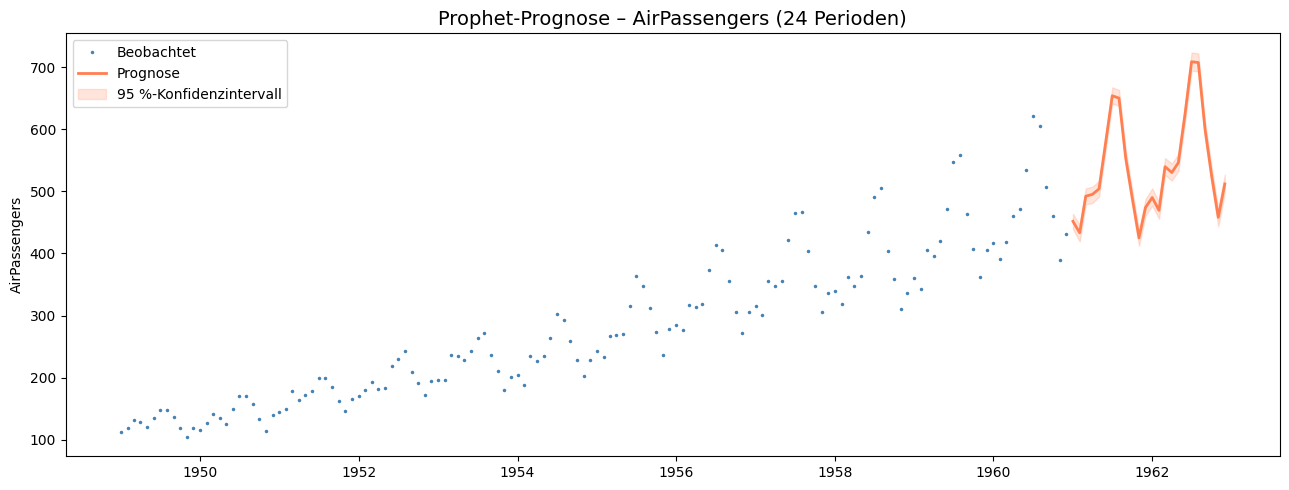


Prognose für 24 Perioden ab 1961-01-01:
        ds  Prognose  Untergrenze  Obergrenze
1961-01-01    451.92       439.41      464.05
1961-02-01    433.39       419.29      446.04
1961-03-01    492.38       479.31      504.98
1961-04-01    495.42       481.58      507.76
1961-05-01    504.22       491.62      517.45
1961-06-01    579.95       566.91      593.10
1961-07-01    654.33       641.72      667.89
1961-08-01    650.56       638.09      663.83
1961-09-01    553.75       540.96      567.05
1961-10-01    489.69       476.97      502.59
1961-11-01    425.11       412.34      437.73
1961-12-01    474.20       461.07      487.67
1962-01-01    490.26       477.30      504.93
1962-02-01    469.56       455.84      482.83
1962-03-01    539.96       526.75      553.78
1962-04-01    530.57       517.44      544.99
1962-05-01    546.40       533.19      559.98
1962-06-01    624.98       611.41      639.57
1962-07-01    709.22       694.70      724.02
1962-08-01    707.97       693.77      

In [16]:
# ╔══════════════════════════════════════════════════════╗
# ║  >>> PROGNOSEHORIZONT EINSTELLEN <<<                 ║
# ╚══════════════════════════════════════════════════════╝

# Anzahl Perioden in die Zukunft
horizont_map = {"MS": 24, "QS": 8, "h": 48}
HORIZONT = horizont_map.get(FREQ, 24)  # <-- bei Bedarf anpassen

# --- Zukunfts-DataFrame erzeugen ---
future = modell.make_future_dataframe(periods=HORIZONT, freq=FREQ)

# Bei logistic growth: Cap/Floor auch für die Zukunft setzen
if GROWTH == "logistic":
    future["cap"] = CAP
    future["floor"] = FLOOR

# --- Prognose ---
forecast = modell.predict(future)

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 5))

# Beobachtete Daten
ax.plot(df["ds"], df["y"], ".", color="steelblue", markersize=3, label="Beobachtet")

# Nur den Prognose-Teil (ab Ende der Beobachtungen)
letzter_ds = df["ds"].iloc[-1]
fc_zukunft = forecast[forecast["ds"] > letzter_ds]

ax.plot(fc_zukunft["ds"], fc_zukunft["yhat"],
        color="coral", linewidth=2, label="Prognose")
ax.fill_between(
    fc_zukunft["ds"],
    fc_zukunft["yhat_lower"],
    fc_zukunft["yhat_upper"],
    color="coral", alpha=0.2, label="95 %-Konfidenzintervall",
)

ax.set_title(f"Prophet-Prognose – {DATENSATZ} ({HORIZONT} Perioden)", fontsize=14)
ax.set_ylabel(DATENSATZ)
ax.legend()
plt.tight_layout()
plt.show()

# --- Prognose-Tabelle ---
print(f"\nPrognose für {HORIZONT} Perioden ab {fc_zukunft['ds'].iloc[0].date()}:")
print(fc_zukunft[["ds", "yhat", "yhat_lower", "yhat_upper"]]
      .rename(columns={"yhat": "Prognose", "yhat_lower": "Untergrenze", "yhat_upper": "Obergrenze"})
      .to_string(index=False, float_format="{:.2f}".format))

---
## Zusammenfassung

| Schritt | Einstellung | Wo anpassen? |
|---------|------------|-------------|
| Datensatz | `DATENSATZ` | Schritt 1 |
| Ausreißer-Schwelle | `SCHWELLE` | Schritt 3 |
| Wachstumsmodell | `GROWTH` | Schritt 4 |
| Saisonalitätsmodus | `SEASONALITY_MODE` | Schritt 5 |
| Zusätzliche Saisonalitäten | `EXTRA_SEASONALITIES` | Schritt 6 |
| Feiertage | `feiertage` | Schritt 6 |
| Externe Regressoren | `EXTRA_REGRESSORS` | Schritt 6 |
| Changepoint-Prior | automatisch via Grid Search | Schritt 9 |
| Saisonalitäts-Prior | automatisch via Grid Search | Schritt 9 |
| Prognosehorizont | `HORIZONT` | Schritt 12 |

### Iterationsschleifen

- **Metriken unbefriedigend** (Schritt 10) → Modellstruktur überdenken ab **Schritt 5** (Saisonalitätsmodus) oder **Schritt 4** (Wachstumsmodell)
- **Muster in Residuen** (Schritt 11) → Features ergänzen ab **Schritt 6**, dann erneut ausführen

**Zum Ausprobieren:** `DATENSATZ` oben ändern und das gesamte Notebook neu ausführen!